# Telco Customer Churn — Exploratory Data Analysis (EDA)

This notebook aims to perform exploratory data analysis on the Telco Customer Churn dataset from Kaggle.

**Objective:** To understand customer churn behavior and gain important insights for the modeling phase.

**The data set includes information about:**

- Customers who left within the last month – the column is called Churn
- Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
- Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
- Demographic info about customers – gender, age range, and if they have partners and dependents

## About the Dataset

**Source:** [Kaggle - Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

| Column | Description | Type |
|-------|----------|-----|
| `customerID` | Customer ID | ID |
| `gender` | Gender (Male/Female) | Categorical |
| `SeniorCitizen` | Whether the customer is 65+ (0/1) | Categorical |
| `Partner` | Has a partner? (Yes/No) | Categorical |
| `Dependents` | Has dependents? (Yes/No) | Categorical |
| `tenure` | Number of months as a customer | Numerical |
| `PhoneService` | Has phone service? (Yes/No) | Categorical |
| `MultipleLines` | Multiple lines? (Yes/No/No phone service) | Categorical |
| `InternetService` | Internet provider (DSL/Fiber optic/No) | Categorical |
| `OnlineSecurity` | Online security (Yes/No/No internet service) | Categorical |
| `OnlineBackup` | Online backup (Yes/No/No internet service) | Categorical |
| `DeviceProtection` | Device protection (Yes/No/No internet service) | Categorical |
| `TechSupport` | Tech support (Yes/No/No internet service) | Categorical |
| `StreamingTV` | TV streaming (Yes/No/No internet service) | Categorical |
| `StreamingMovies` | Movie streaming (Yes/No/No internet service) | Categorical |
| `Contract` | Contract term (Month-to-month/One year/Two year) | Categorical |
| `PaperlessBilling` | Paperless billing (Yes/No) | Categorical |
| `PaymentMethod` | Payment method | Categorical |
| `MonthlyCharges` | Monthly amount charged (USD) | Numerical |
| `TotalCharges` | Total amount charged (USD) | Numerical |
| `Churn` | **Target: Did the customer churn? (Yes/No)** | Categorical |

In [38]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data.load_data import load_raw_data

os.chdir("..")

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
pd.set_option("display.max_columns", None)

## 1. Data Loading and First Look

We load the data using the `load_raw_data()` function in the `src/data/load_data.py` module. This keeps the data loading logic centralized.

In [37]:
df = load_raw_data()
print(f"Dataset Size: {df.shape}\n")
df.head()

Dataset Size: (7043, 21)



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [11]:
missing = df.isnull().sum()
missing[missing > 0]

TotalCharges    11
dtype: int64

### 1. Findings:
- The dataset contains **7043 rows** and **21 columns**.
- `customerID`: Unique identifier for each customer.
- **Target variable:** `Churn` (Yes/No).
- **3 numerical** columns: `tenure`, `MonthlyCharges`, and `TotalCharges`.
- **17 categorical** columns: Mostly in Yes/No format.
- `SeniorCitizen` is unique — encoded as 0/1 but represents a categorical feature.
- Only `TotalCharges` contains 11 NaN values.

---

## 2. Target Variable Analysis (Churn)

We are examining the distribution of Churn. This is critical for understanding whether **class imbalance** exists in binary classification problems.

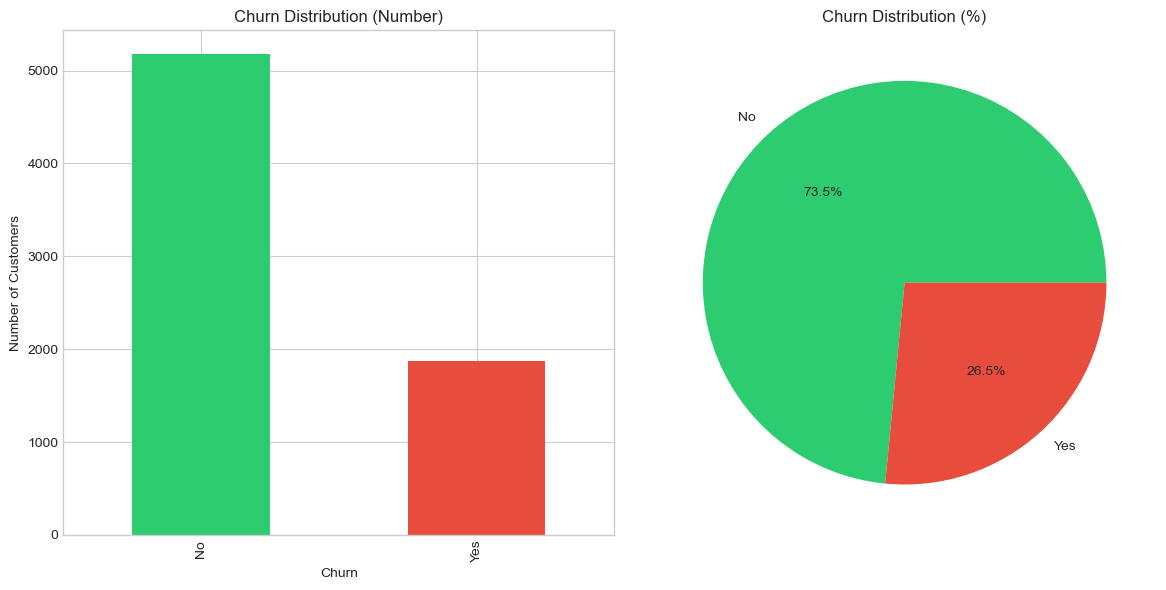

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Numerical Distribution
df["Churn"].value_counts().plot(kind="bar", ax=axes[0], color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Churn Distribution (Number)")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Number of Customers")

# Percentage Distribution
df["Churn"].value_counts(normalize=True).plot(kind="pie", ax=axes[1], autopct="%1.1f%%", colors=["#2ecc71", "#e74c3c"])
axes[1].set_title("Churn Distribution (%)")

plt.tight_layout()
plt.show()

### 2. Findings:
- **No (Non-churned):** ~73.5% — 5174 customers
- **Yes (Churned):** ~26.5% — 1869 customers
- **Class imbalance exists** — the churned customer ratio is approximately 1:3.

---

## 3. Basic Statistics

In [17]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


### 3. Findings:
- **tenure:** Mean ~32 months, median 29 months. Min 0, max 72. Shows a wide distribution.
- **MonthlyCharges:** Mean ~64.76 USD, median ~70.35 USD. Ranges from 18.25 USD to 118.75 USD.
- **TotalCharges:** Mean ~2283 USD, std ~2266 USD. High variance — significant difference between long-term and new customers.
- `SeniorCitizen` mean 0.16 — approximately 16% of customers are seniors.

---

## 4. Numerical Variable Distributions

Examining how tenure, MonthlyCharges, and TotalCharges are distributed across all customers.


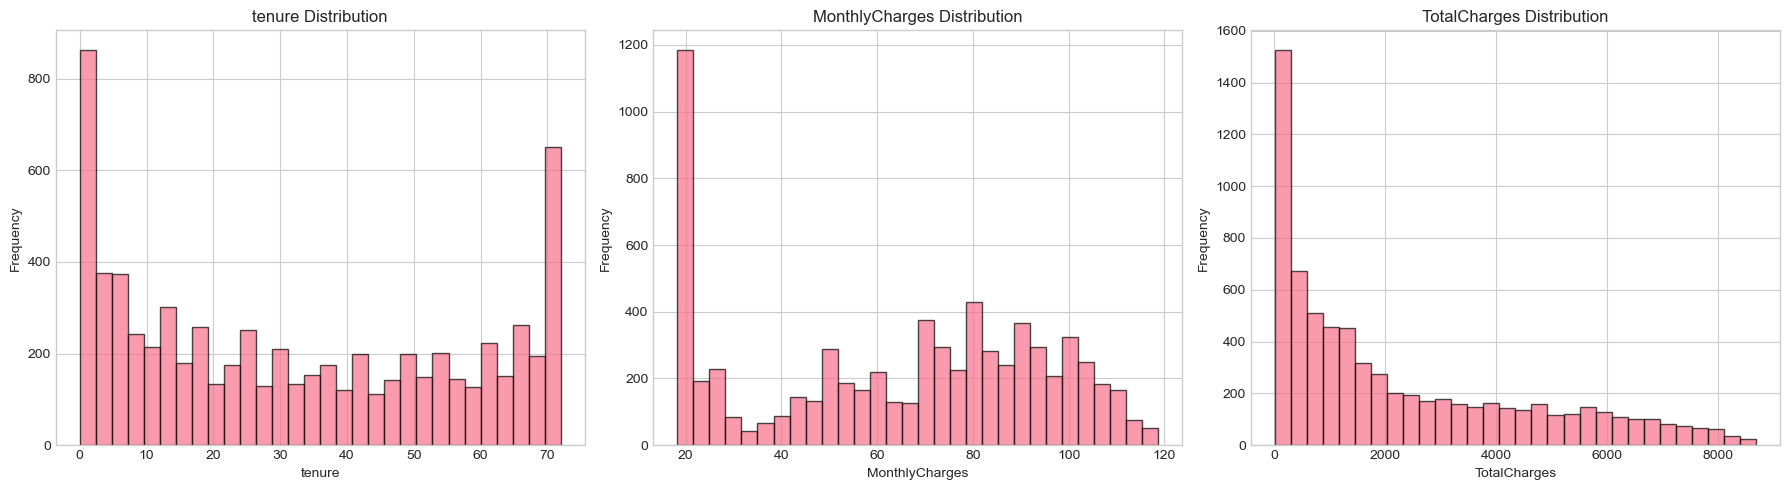

In [31]:
numerical_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(), bins=30, edgecolor="black", alpha=0.7)
    axes[i].set_title(f"{col} Distribution")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### 4. Findings:
- **tenure:** Shows a U-shaped (bimodal) distribution — many customers are either very new (0-5 months) or long-term (65-72 months), with fewer in between.
- **MonthlyCharges:** There is a **massive peak at the lower end (~20 USD)**, indicating a large segment of customers on basic/entry-level plans. 
- **TotalCharges:** The highest concentration of customers is in the lowest bracket (0-500 USD), with the frequency dropping sharply as charges increase.

---

## 5. Numerical Variables — Churn Comparison

Comparing the distribution of each numerical variable by churn status to identify patterns.


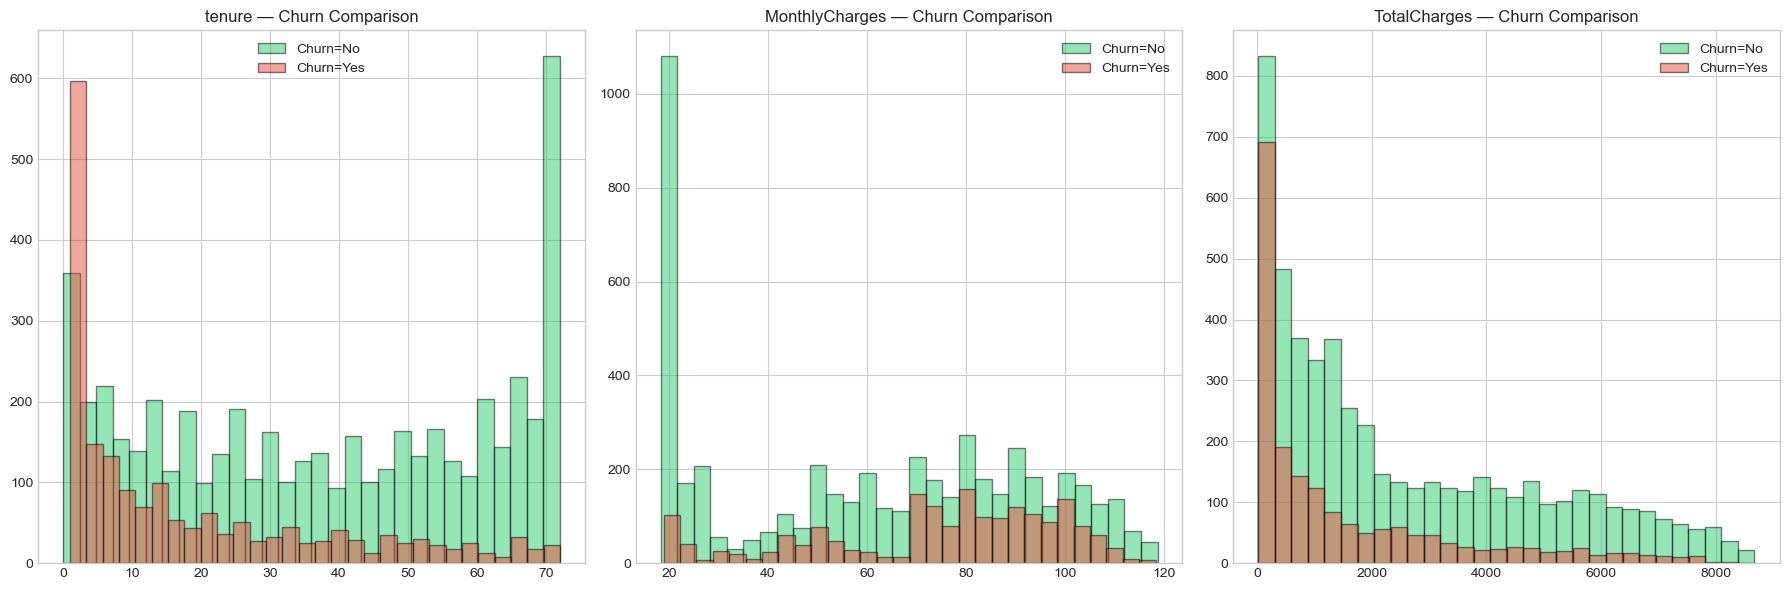

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(numerical_cols):
    for label, color in zip(["No", "Yes"], ["#2ecc71", "#e74c3c"]):
        axes[i].hist(
            df[df["Churn"] == label][col].dropna(),
            bins=30,
            alpha=0.5,
            label=f"Churn={label}",
            color=color,
            edgecolor="black",
        )
    axes[i].set_title(f"{col} — Churn Comparison")
    axes[i].legend()

plt.tight_layout()
plt.show()

### 5. Findings:
- **tenure:** Customers with low tenure (0-10 months) have significantly higher churn rates. Long-term customers (50+ months) are much more likely to stay.
- **MonthlyCharges:** Churned customers tend to have higher monthly charges (60 USD - 110 USD range), while non-churned customers are more evenly spread.
- **TotalCharges:** Churned customers tend to cluster at lower total charges, confirming they are relatively new customers.

---

## 6. Categorical Variables — Churn Analysis

Analyzing how each categorical variable relates to churn to identify key drivers.


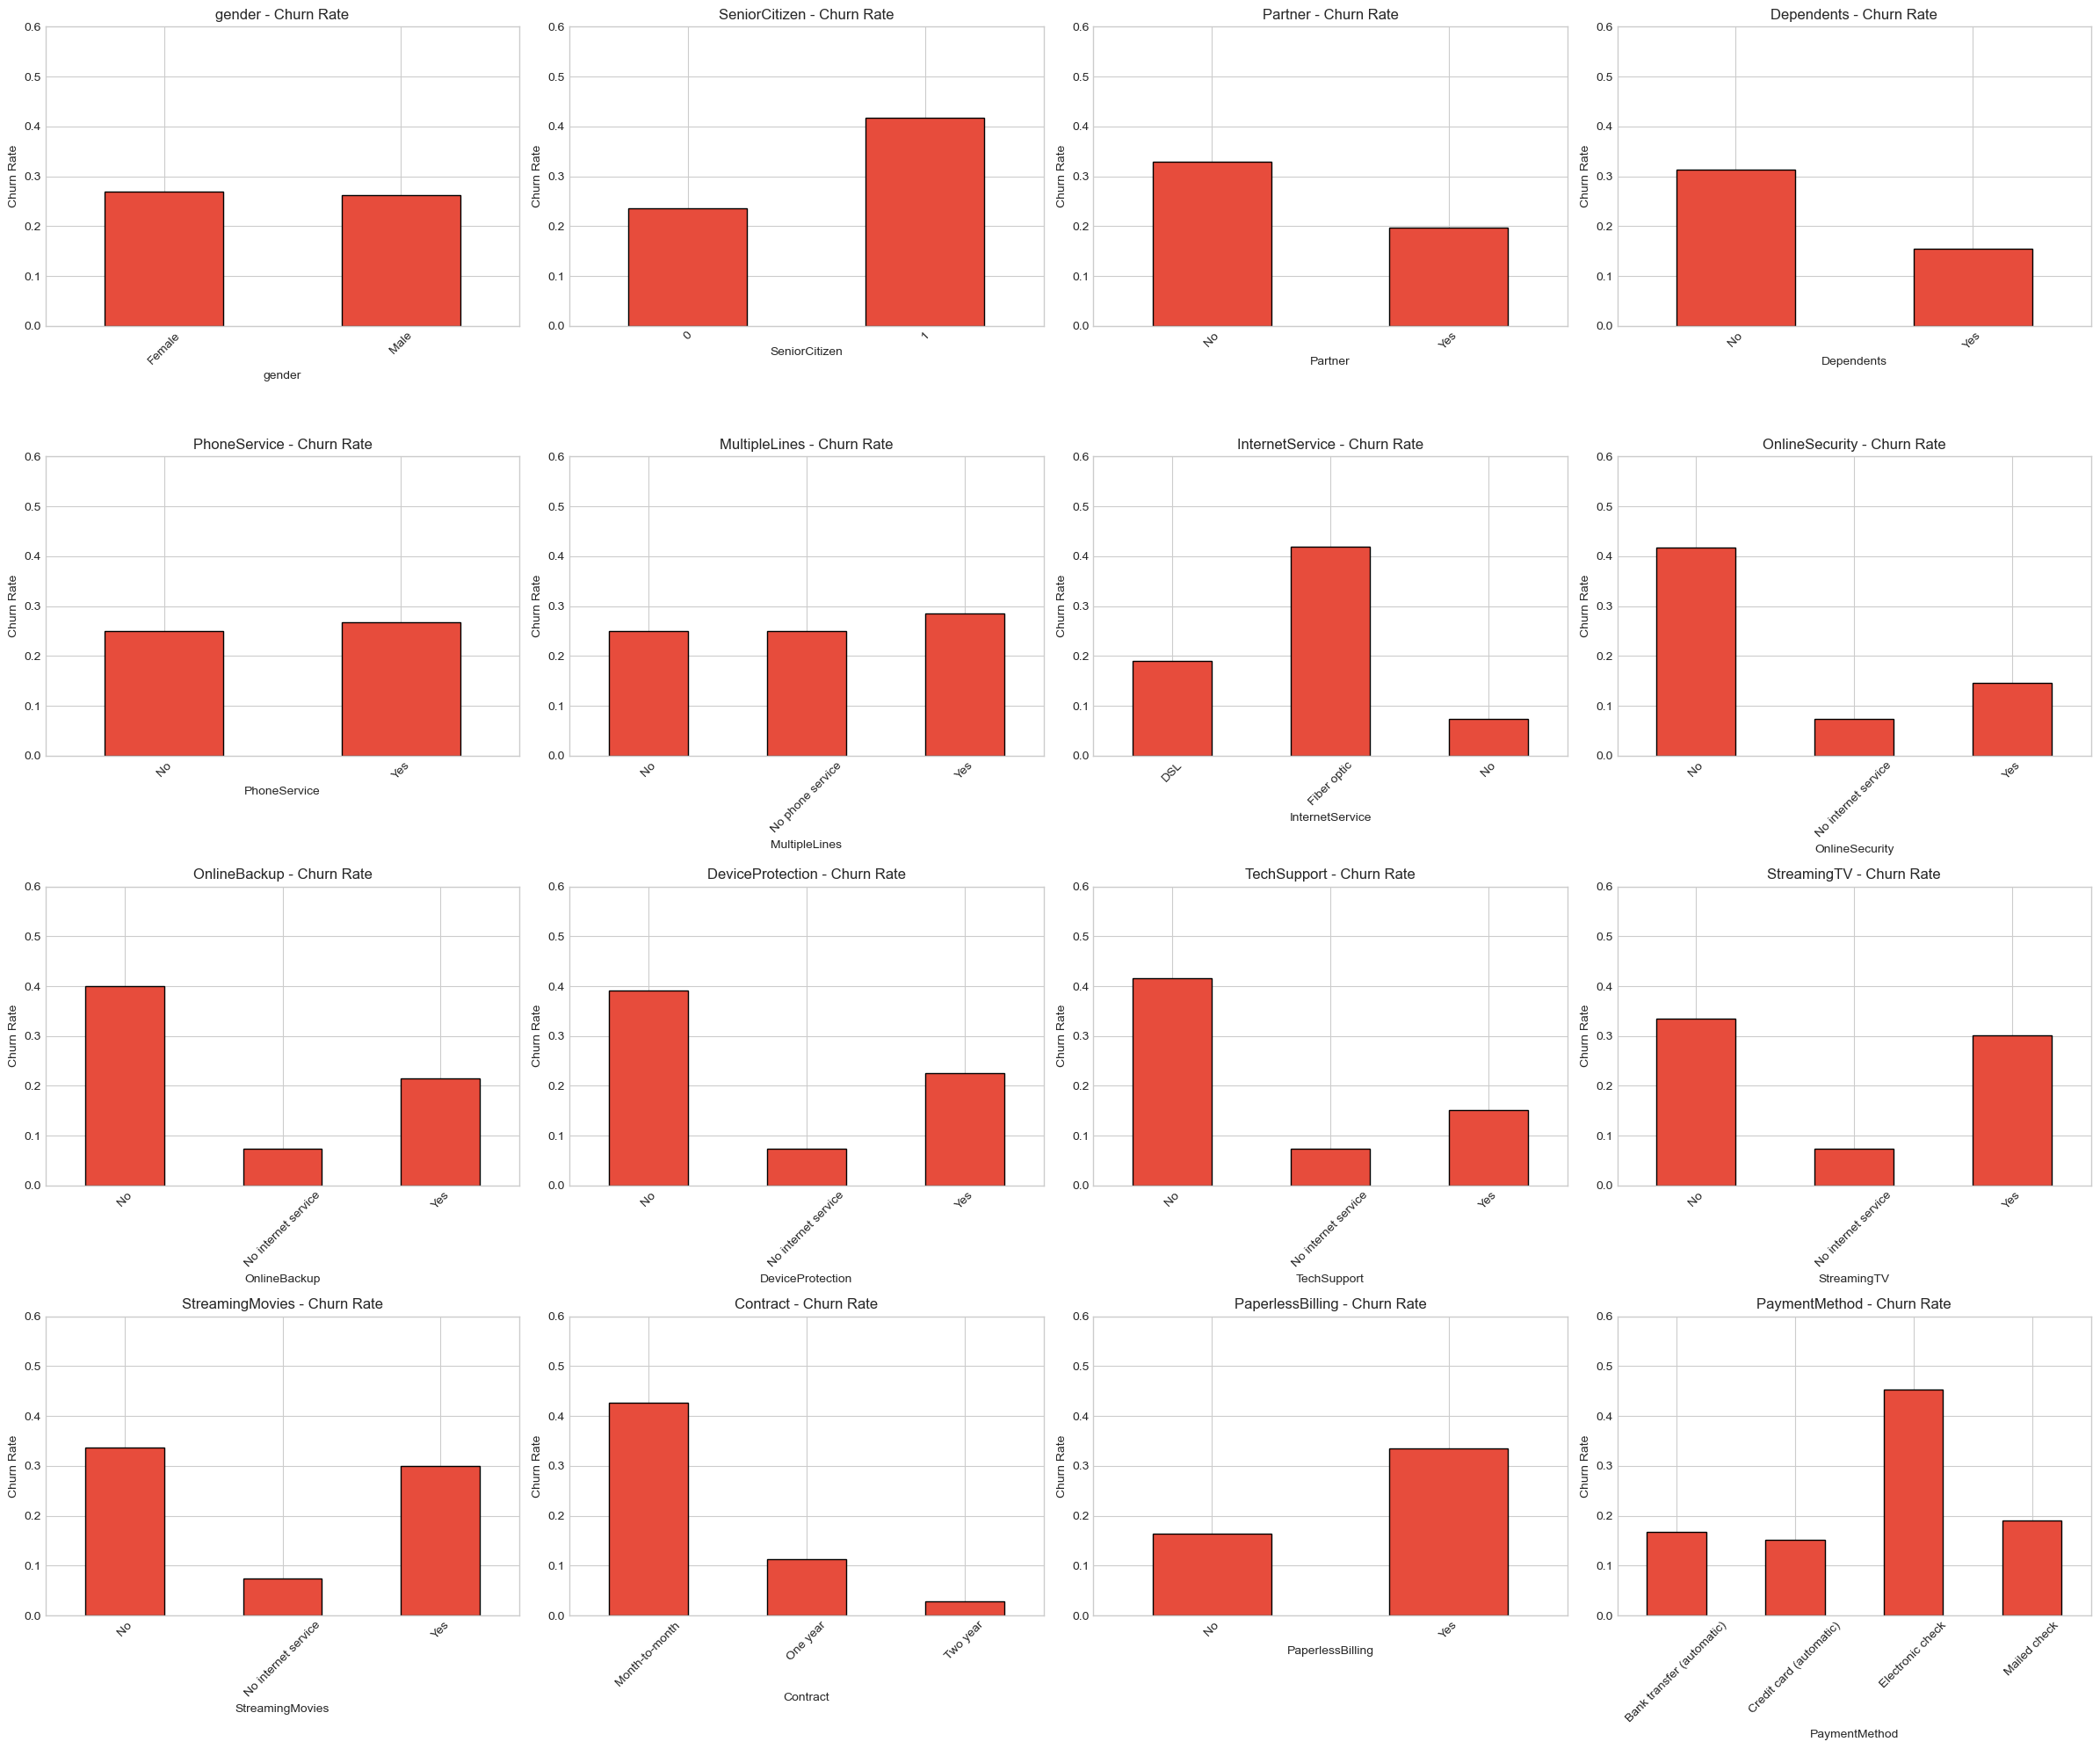

In [36]:
categorical_cols = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
]

fig, axes = plt.subplots(4, 4, figsize=(24, 20))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    churn_rate = df.groupby(col)["Churn"].apply(lambda x: (x == "Yes").mean())
    churn_rate.plot(kind="bar", ax=axes[i], color="#e74c3c", edgecolor="black")
    axes[i].set_title(f"{col} - Churn Rate")
    axes[i].set_ylabel("Churn Rate")
    axes[i].set_ylim(0, 0.6)
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### 6. Findings:
- **InternetService:** Fiber optic customers have a significantly higher churn rate compared to DSL and No Internet customers. This may indicate dissatisfaction with fiber optic service quality or pricing.
- **OnlineSecurity / OnlineBackup / DeviceProtection / TechSupport:** Customers without these add-on services (No) churn at much higher rates. These services appear to act as retention factors — customers who subscribe to them are more "invested" in the provider.
- **Contract:** Month-to-month contract customers have dramatically higher churn rates. One-year and two-year contracts show significantly lower churn. This is the strongest categorical predictor of churn.
- **PaymentMethod:** Electronic check users churn at the highest rate. Automatic payment methods (bank transfer, credit card) show much lower churn, suggesting that customers with automatic payments are more committed.

**Key Insight:** The combination of month-to-month contract + fiber optic internet + no add-on services + electronic check payment represents the highest-risk customer profile for churn.

---

## 7. Correlation Analysis

Examining correlations between numerical variables to understand relationships and identify potential multicollinearity issues for modeling.


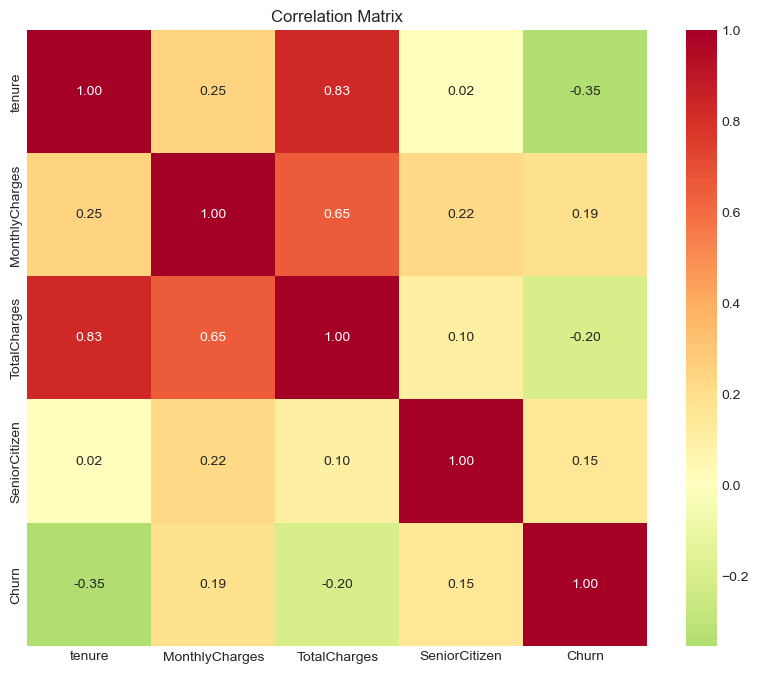

In [34]:
df_corr = df.copy()
df_corr["Churn"] = (df_corr["Churn"] == "Yes").astype(int)

plt.figure(figsize=(10, 8))
correlation = df_corr[["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn"]].corr()
sns.heatmap(correlation, annot=True, cmap="RdYlGn_r", center=0, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

### 7. Findings:
- **tenure & TotalCharges:** Strong positive correlation (~0.83). This is expected — the longer a customer stays, the more they pay in total.
- **MonthlyCharges & TotalCharges:** Moderate positive correlation (~0.65). Higher monthly charges lead to higher total charges over time.
- **tenure & MonthlyCharges:** Weak correlation. Monthly charges are relatively independent of how long a customer has been with the company.

**Note for modeling:** The strong correlation between tenure and TotalCharges suggests potential multicollinearity. During feature engineering, we may need to address this (e.g., by creating a ratio feature or dropping one of them).


---

## Summary

### Data Quality
- 7043 customers, 21 columns
- Only 11 missing values in TotalCharges — likely new customers with tenure = 0
- No other missing data issues
- SeniorCitizen is encoded as 0/1 but is actually categorical

### Key Findings
1. **Class Imbalance:** Churn rate is ~26.5% (1:3 ratio). This needs to be addressed during modeling (e.g., SMOTE, class_weight).
2. **tenure:** Bimodal distribution. Short-tenure customers (0-10 months) churn at much higher rates. Long-term customers (50+ months) rarely churn.
3. **MonthlyCharges:** Churned customers tend to have higher monthly charges ($60-$110 range).
4. **Contract:** Month-to-month contracts are the strongest predictor of churn. Long-term contracts significantly reduce churn risk.
5. **Add-on Services:** Customers without OnlineSecurity, OnlineBackup, DeviceProtection, and TechSupport churn at much higher rates.
6. **InternetService:** Fiber optic customers churn more than DSL customers.
7. **PaymentMethod:** Electronic check users have the highest churn rate.
8. **Correlation:** tenure and TotalCharges are strongly correlated (~0.83), which may cause multicollinearity in models.

### Feature Engineering Ideas
- Create `tenure_group` feature (e.g., 0-12, 13-24, 25-48, 49-72 months) to capture non-linear relationship
- Create `monthly_to_total_ratio` (MonthlyCharges / TotalCharges) to capture customer value efficiency
- Create `num_services` feature counting total add-on services subscribed (OnlineSecurity, OnlineBackup, etc.)
- Convert SeniorCitizen from 0/1 to categorical Yes/No for consistency
- Consider binary encoding for high-churn indicators (e.g., is_month_to_month, is_fiber_optic, is_electronic_check)

### Next Step
Preprocessing and Feature Engineering (Phase 2)
